In [1]:
import matplotlib.pyplot as plt
%matplotlib inline

import numpy as np

import src.data_loading.optimam_preprocessor as optimam_preprocessor
from pathlib import Path
data_path = "../../Data/sample_data_omi_db/DATA"
exams_path = EXAMS_PATH="../../Data/sample_data_omi_db/IMAGES"
sample_input_path = 'omi_db_data'
config = optimam_preprocessor.DatabaseConfig(
    data_path=Path(data_path),
    images_path=Path(exams_path),
    output_path=Path(sample_input_path)
)

from src.image_preprocessings.image_preprocessings import read_xray, flip_image_left, image_resize, hist_equalization, pad_to_aspect_ratio, crop_image

In [2]:
preprocessor = optimam_preprocessor.OptimamPreprocessor(config)
exam_list, img_paths = preprocessor.create_exam_list(100)

R
CC
NO


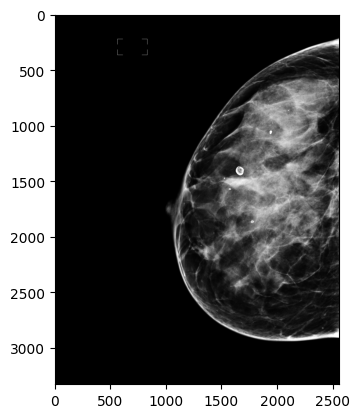

In [3]:
inx = 52 # 52 # 39 with line artifacts
inx2 = 0
while True:
    img_path = img_paths[inx][inx2]
    dicom_path = preprocessor.config.images_path / img_path
    dicom_file, image = read_xray(str(dicom_path))
    if dicom_file.ImageLaterality == 'R' and dicom_file.ViewPosition == 'CC':
        break
    inx2 += 1
    if inx2 >= len(img_paths[inx]):
        print('no image found')
        break
if inx2 < len(img_paths[inx]):
    print(dicom_file.ImageLaterality)
    print(dicom_file.ViewPosition)
    print(dicom_file.FieldOfViewHorizontalFlip)
    #print(dicom_file.PixelSpacing)

    plt.imshow(image, cmap=plt.cm.gray)

In [4]:
dicom_file, image = flip_image_left(dicom_file, image)

flipping R view shown right to left


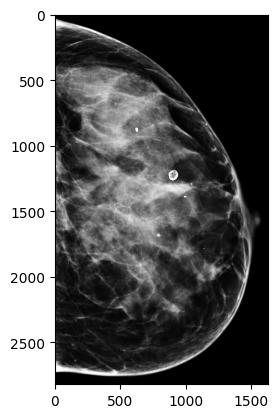

In [5]:
# cropping according to authors of the NYU model
cropped_image = crop_image(dicom_file, image)
plt.imshow(cropped_image, cmap=plt.cm.gray)

target image size (1300, 1000)  with aspect ratio:  1.3
current image size (2821, 1628)  with aspect ratio:  1.7328009828009827
padded image size (2821, 2170)  with aspect ratio:  1.3


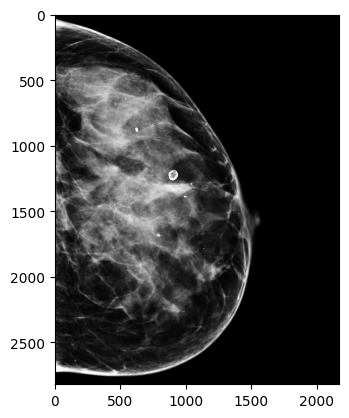

In [6]:
# Pad cropped image to the ratio of a designated height and width
target_size = (1300, 1000)
target_aspect_ratio = target_size[0]/target_size[1]
print('target image size', target_size, ' with aspect ratio: ', target_aspect_ratio)
# Idea: Zero-pad cropped_image to arrive at aspect ratio
current_ratio = cropped_image.shape[0]/cropped_image.shape[1]
print('current image size', cropped_image.shape, ' with aspect ratio: ', current_ratio)

padded_image = pad_to_aspect_ratio(cropped_image, target_aspect_ratio)
padded_ratio = padded_image.shape[0]/padded_image.shape[1]
print('padded image size', padded_image.shape, ' with aspect ratio: ', padded_ratio)
plt.imshow(padded_image, cmap=plt.cm.gray)

rescaled ratio 1.3
rescaled image size (1300, 1000)


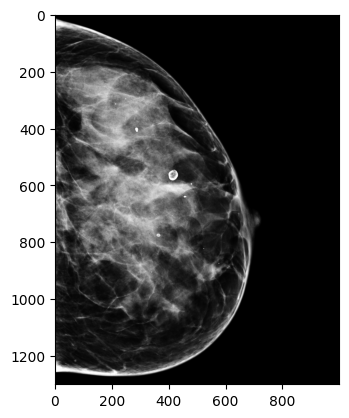

In [7]:
# Rescale image at equal ratio to the designated height and width
rescaled_image = image_resize(padded_image, width = target_size[1], height = None)
rescaled_ratio = padded_image.shape[0]/padded_image.shape[1]
print('rescaled ratio', rescaled_ratio)
print('rescaled image size', rescaled_image.shape)

plt.imshow(rescaled_image, cmap=plt.cm.gray)

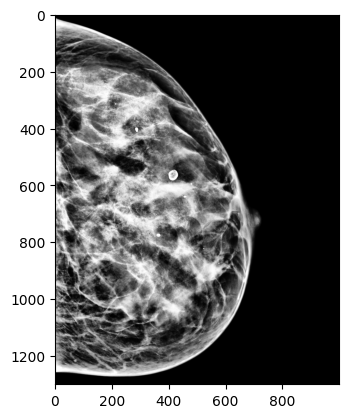

In [8]:
# Note: Cropping failed when applying hist_equalization in advance!!
he_image = hist_equalization(rescaled_image, castType = np.uint16, clipLimit = 10.0)
plt.imshow(he_image, cmap=plt.cm.gray)

In [9]:
dicom_file.keys

<bound method Dataset.keys of Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 206
(0002,0001) File Meta Information Version       OB: b'\x01\x00'
(0002,0002) Media Storage SOP Class UID         UI: Digital Mammography X-Ray Image Storage - For Presentation
(0002,0003) Media Storage SOP Instance UID      UI: 1.2.826.0.1.3680043.9.3218.1.1.3866541.1754.1511400095328.9412.0
(0002,0010) Transfer Syntax UID                 UI: Explicit VR Little Endian
(0002,0012) Implementation Class UID            UI: 1.3.6.1.4.1.22213.1.143
(0002,0016) Source Application Entity Title     AE: 'DCMPseudonymiser'
-------------------------------------------------
(0008,0005) Specific Character Set              CS: 'ISO_IR 100'
(0008,0008) Image Type                          CS: ['DERIVED', 'SECONDARY']
(0008,0016) SOP Class UID                       UI: Digital Mammography X-Ray Image Storage - For Presentation
(0008,0018) SOP Instance UID                